### Setup Environment

In [1]:
!git clone https://github.com/NhuGiap04/Fk-Diffusion-Steering.git

Cloning into 'Fk-Diffusion-Steering'...
remote: Enumerating objects: 363, done.
remote: Counting objects: 100% (99/99), done.
remote: Compressing objects: 100% (41/41), done.
remote: Total 363 (delta 74), reused 58 (delta 58), pack-reused 264 (from 2)
Receiving objects: 100% (363/363), 196.58 MiB | 13.97 MiB/s, done.
Resolving deltas: 100% (200/200), done.


In [1]:
%cd Fk-Diffusion-Steering
!git pull

/content/Fk-Diffusion-Steering
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 6 (delta 4), reused 6 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 1.51 MiB | 4.56 MiB/s, done.
From https://github.com/NhuGiap04/Fk-Diffusion-Steering
   1085cfa..c94a5d3  main       -> origin/main
Updating 1085cfa..c94a5d3
Fast-forward
 Evolve_Steering.ipynb                            | 118 ++++++++++++++++++++---
 text_to_image/evolve_diffusers/steer_pipeline.py |  11 ++-
 2 files changed, 112 insertions(+), 17 deletions(-)


In [2]:
%pip install -r requirements.txt -q

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Building editable for diffusers (pyproject.toml) ... done


### Evolve Steering

In [3]:
%cd text_to_image

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = ''
# os.environ['HF_HOME'] = ''

import json
import argparse
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
from PIL import Image

import torch
from diffusers import DDIMScheduler

/content/Fk-Diffusion-Steering/text_to_image


In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from diffusers import DDIMScheduler
from evolve_diffusers import BaseSDXL

device = "cuda" if torch.cuda.is_available() else "cpu"

pipe = BaseSDXL.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32,
)
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
pipe = pipe.to(device)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`
loop=1/3 use_stein=False best_reward=1.8251 mean_reward=0.9208 std_reward=0.9915 threshold=1.4166 accepted=4 rejected=4 accepted_pool=4 rejected_pool=4


  0%|          | 0/50 [00:00<?, ?it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`
loop=2/3 use_stein=True best_reward=1.7973 mean_reward=0.4833 std_reward=1.4047 threshold=1.6231 accepted=3 rejected=5 accepted_pool=6 rejected_pool=10


  0%|          | 0/50 [00:00<?, ?it/s]

`metric_to_chase` will be ignored as it only applies to 'LLMGrader' as the `reward_name`
loop=3/3 use_stein=True best_reward=1.7873 mean_reward=0.0056 std_reward=1.1044 threshold=1.4730 accepted=1 rejected=7 accepted_pool=7 rejected_pool=17


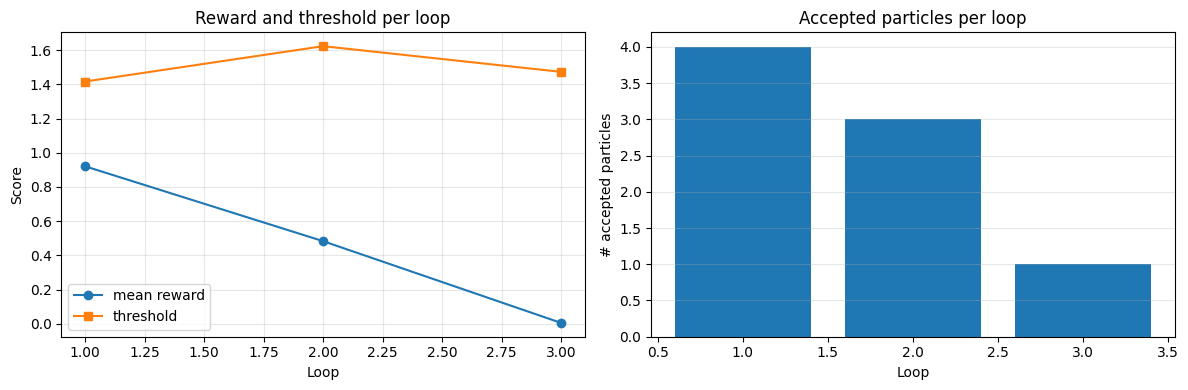

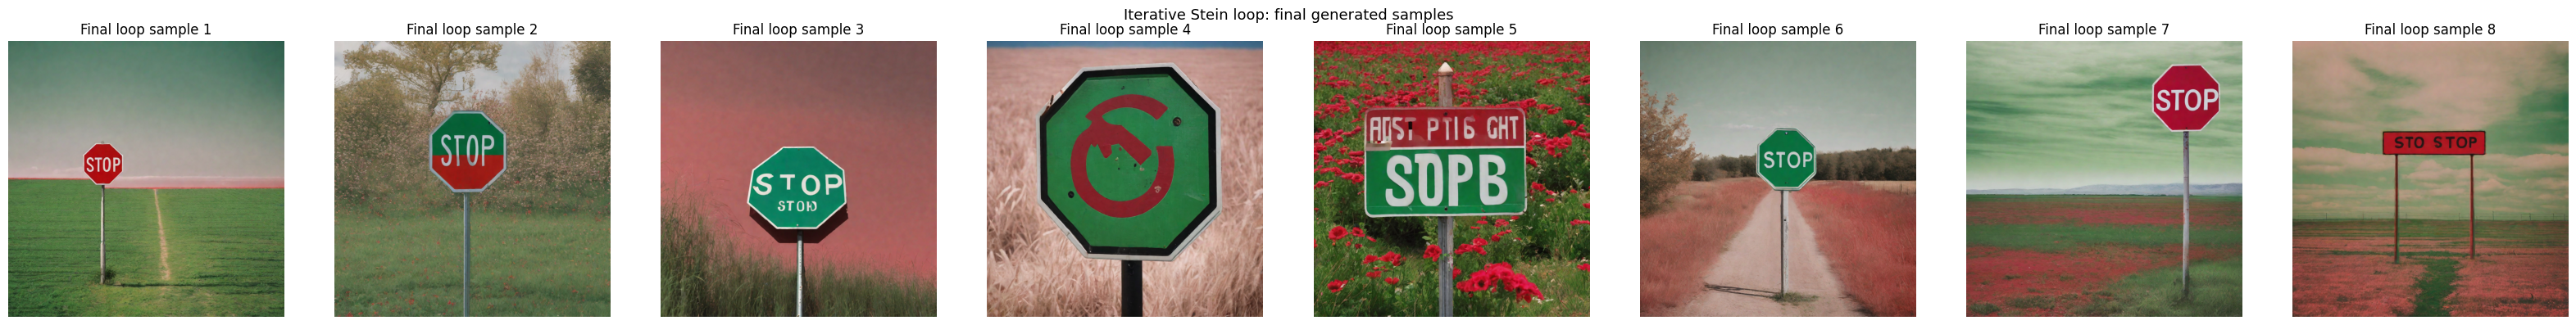

Best mean reward: 0.9208011627197266
Best reward: 1.7872822284698486
Std reward: 1.1043697595596313
Num loops returned: 3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from evolve_diffusers.steer_pipeline import iterative_sample_with_stein


def iterative_stein_loop(
    model,
    prompt,
    *,
    num_loops=4,
    num_particles=4,
    steer_start_timestep=200,
    steer_end_timestep=20,
    base_threshold=0.0,
    stein_step_size=0.04,
    stein_bandwidth=None,
    stein_rejected_penalty=0.0,
    stein_num_steps=1,
    num_inference_steps=50,
    guidance_scale=5.0,
    guidance_reward_fn="ImageReward",
    max_images_to_show=4,
):
    """Run iterative Stein steering and display loop-level diagnostics + final images."""
    out = iterative_sample_with_stein(
        model=model,
        prompt=prompt,
        num_loops=num_loops,
        num_particles=num_particles,
        steer_start_timestep=steer_start_timestep,
        steer_end_timestep=steer_end_timestep,
        base_threshold=base_threshold,
        stein_step_size=stein_step_size,
        stein_bandwidth=stein_bandwidth,
        stein_rejected_penalty=stein_rejected_penalty,
        stein_num_steps=1,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        guidance_reward_fn=guidance_reward_fn,
    )

    mean_rewards = [float(r.mean().item()) for r in out["rewards"]]
    accepted_counts = [int(a.shape[0]) for a in out["accepted"]]
    thresholds = out["thresholds"]
    loop_idx = np.arange(1, len(mean_rewards) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(loop_idx, mean_rewards, marker="o", label="mean reward")
    axes[0].plot(loop_idx, thresholds, marker="s", label="threshold")
    axes[0].set_xlabel("Loop")
    axes[0].set_ylabel("Score")
    axes[0].set_title("Reward and threshold per loop")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].bar(loop_idx, accepted_counts)
    axes[1].set_xlabel("Loop")
    axes[1].set_ylabel("# accepted particles")
    axes[1].set_title("Accepted particles per loop")
    axes[1].grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()

    final_images = out["results"][-1].images
    n = min(max_images_to_show, len(final_images))
    fig, ax = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        ax = [ax]

    for i in range(n):
        ax[i].imshow(final_images[i])
        ax[i].axis("off")
        ax[i].set_title(f"Final loop sample {i + 1}")

    fig.suptitle("Iterative Stein loop: final generated samples", fontsize=13)
    fig.tight_layout()
    plt.show()

    return out


if "pipe" not in globals():
    raise RuntimeError("Run the steer_sample setup cell first so `pipe` is defined.")

loop_out = iterative_stein_loop(
    model=pipe,
    prompt="a photo of a green stop sign in a red field",
    num_loops=3,
    num_particles=8,
    steer_start_timestep=400,
    steer_end_timestep=150,
    stein_step_size=0.0005,
    stein_rejected_penalty=0.5,
    stein_num_steps=10,
    num_inference_steps=50,
    guidance_scale=5,
    max_images_to_show=8,
)

print("Best mean reward:", loop_out["best_mean_reward"])
print("Best reward:", loop_out["best_reward"])
print("Std reward:", loop_out["std_reward"])
print("Num loops returned:", len(loop_out["results"]))